In [16]:
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel, Box1DKernel
from scipy.signal import argrelmin, argrelmax

from pipeline.processing.remove_spikes import remove_spikes
from pipeline.processing.fit_continuum import fit_continuum
from pipeline.processing.get_absorption_intervals import get_absorption_intervals
from pipeline.processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from pipeline.processing.measure_line import measure_line
from pipeline.processing.scale_civ_to_nv import scale_civ_to_nv
from pipeline.processing.utility_functions import *
from pipeline.processing.parameters import CIV_CONTINUUM_WINDOWS, CIV_FIT_WINDOW, LYA_NV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, CIV_AIR, NV_AIR, LYA_AIR, BAL_MIN_WIDTH
from utility.get_intercepts_near_line import get_intercepts_near_line

settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False,
        'mathtext.fontset':'stix',
        'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings) 

spectra_hdf5_path = "data/spectra.h5"
verbose=True

In [4]:
# 2305843036556367200
idx = 2780881429200899

In [ ]:
with h5py.File(spectra_hdf5_path, "r") as f:
        data = f[f"{idx}"][()]
        
lam = data[0,:]
flux = data[1,:]
ivar = data[2,:]

# Note: preprocessing (redshift removal and bad pixel masking) already done in retrieval pipeline

# create noise
noise = np.abs(1/np.sqrt(ivar))

# remove spikes
flux_clean, _ = remove_spikes(lam=lam,flux=flux,ivar=ivar)


#------------------------------------------------------------------------------------


result_civ_cont, continuum_civ, _ = fit_continuum(lam=lam, flux=flux_clean, ivar=ivar, windows=CIV_CONTINUUM_WINDOWS, lambda_ref=1700.0)

# subtract CIV continuum
flux_sub_civ = flux_clean - continuum_civ

# # get absorption mask
# civ_absorption_intervals, civ_absorption_mask, civ_blue_absorption_detected, civ_center_absorption_detected = get_absorption_intervals(lam=lam, flux=flux_clean, flux_sub=flux_sub_civ, continuum=continuum_civ, noise=noise, window=CIV_FIT_WINDOW, verbose=verbose)

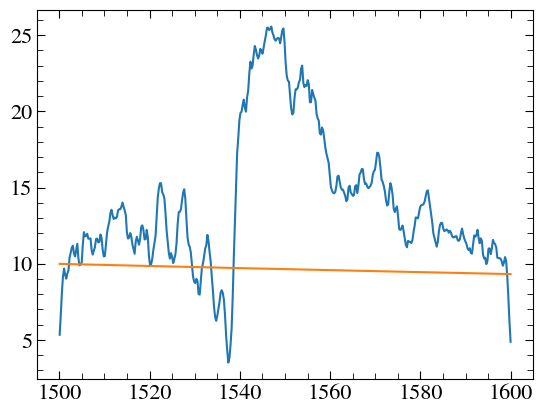

In [ ]:
window = CIV_FIT_WINDOW
min_width_aa=BAL_MIN_WIDTH

mask = (lam > window[0]) & (lam < window[1])

lam_local, flux_local, flux_sub_local, noise_local = lam[mask], flux[mask], flux_sub_civ[mask], noise[mask]

continuum_local = continuum_civ[mask]

# center_absorption, blue_absorption = None, None
blue_absorption_found, center_absorption_found = False, False
absorption_intervals = []


## BLUE ABSORPTION
# use rolling mean because we want to smooth but stay as much to the original values as possible
flux_conv_mean = convolve(flux_local,Box1DKernel(5))

# get indeces of "global" minimum and maximum
max_idx = np.argmax(flux_conv_mean)

if max_idx > 10:  # in case the max is too close to beginning for some reason
    min_idx = np.argmin(flux_conv_mean[:max_idx])  # min index on left (blue) side of maximum

    if flux_conv_mean[min_idx] < continuum_local[min_idx] - noise_local[min_idx]:
        try:
            # get the two intersections of the flux and the continuum that are closest (to the lam value of) the minimum
            blue_absorption = get_intercepts_near_line(lam_local,lower_flux=continuum_local,upper_flux=flux_conv_mean,x_val=lam_local[min_idx])
            if blue_absorption[1] - blue_absorption[0] >= min_width_aa:
                absorption_intervals.append(blue_absorption)
                blue_absorption_found = True
        except IndexError:
            if verbose:
                print("IndexError while trying to find blue absorption boundaries")
            if lam_local[min_idx] - lam_local[0] >= min_width_aa:
                blue_absorption_found = True

plt.plot(lam_local,flux_conv_mean)
plt.plot(lam_local,continuum_local)